# Marcelo Guesser — Walkthrough

This notebook walks through the **complete architecture** of the **Router-based Multi-Strategy Guesser**: an approach that answers the quiz questions entirely on a CPU-only machine under tight RAM constraints, routing each question to the most appropriate strategy (RAG, web search, or code execution) based on its theme.

# Notebook Parts

1. **The problem** and the hardware constraints that shaped every design decision
2. **The Router-based Hybrid architecture** that picks a different strategy per theme
3. **Strategy 1 — RAG** (used for Science, Entertainment, Philosophy)
4. **Strategy 2 — Web Search** (used for History, News)
5. **Math theme**: The nightmare theme
6. The **integrated `GuesserEngine`** orchestrating everything
7. **Experiments, Results & Conclusions**
8. **References**

---

> **Note:** Claude Code was used to:
> - Help develop the architecture diagrams
> - Help generate the analysis code for extracting metrics (time, accuracy, model size, etc., broken down by theme)

## Part 1 — The Constraints

### The hardware
Everything runs locally on a **Snapdragon X Elite** machine (Windows on ARM, CPU-only — Ollama does not support the integrated Adreno GPU nor the Hexagon NPU).

### The constraints that shaped the design

| Limitation | Impact |
|---|---|
| **RAM pressure** (~12 GB free) | Cannot fit 7 or even 14B+ models — must pick small, specialized models per theme |
| **Cold-start overhead** | Models get evicted from memory → 2–5s overhead per swap |
| **CPU-only inference** (no GPU) | ~3–5 tok/s for 3B models; long contexts inflate prompt processing time and cause timeouts |

In [2]:
# Setup: ensure both project and Marcelo are in sys.path
import os, sys
notebook_dir = os.path.abspath(os.getcwd())
marcelo_root = notebook_dir if notebook_dir.endswith('Marcelo') else os.path.join(notebook_dir, 'Marcelo')
project_root = os.path.dirname(marcelo_root)
for p in (project_root, marcelo_root):
    if p not in sys.path:
        sys.path.insert(0, p)

print('project_root:', project_root)
print('marcelo_root:', marcelo_root)

project_root: c:\Users\marce\Desktop\Code\NLP_Assignment
marcelo_root: c:\Users\marce\Desktop\Code\NLP_Assignment\Marcelo


In [6]:
# Sanity check: which models are currently loaded in Ollama?
import subprocess
try:
    result = subprocess.run(['ollama', 'ps'], capture_output=True, text=True, check=True)
    print(result.stdout)
except Exception as e:
    print(f'Could not query Ollama (is it running?): {e}')

NAME               ID              SIZE      PROCESSOR    CONTEXT    UNTIL   
gemma3:4b          a2af6cc3eb7f    5.3 GB    100% CPU     4096       Forever    
qwen2.5:0.5b       a8b0c5157701    693 MB    100% CPU     4096       Forever    
qwen2-math:1.5b    a4fdda0c6cc5    1.6 GB    100% CPU     4096       Forever    



## Part 2 — The Architecture: Router-based Hybrid

Instead of using one large general-purpose model for every theme, we **route each question to a different strategy** based on the theme. The PoliMillionaire client provides the theme separately, so no additional classification step is needed.

```
                       ┌──────────────────┐
    Question ─────────►│      Router      │
                       └──────────────────┘
                                │
          ┌─────────────┬───────┴───────┬─────────────┐
          ▼             ▼               ▼             ▼
     ┌────────┐    ┌──────────┐    ┌────────┐   ┌──────────┐
     │  RAG   │    │  SEARCH  │    │  POT   │   │  THEORY  │
     │(local) │    │   (web)  │    │ (code) │   │ (direct) │
     └────────┘    └──────────┘    └────────┘   └──────────┘
          │             │               │             │
          ▼             ▼               ▼             ▼
     Sci/Ent/Phil   Hist/News        Math (calc)   Math (theory)
```

Each theme has a **`ThemeConfig`** that declares its approach, model, prompt, thresholds, etc. The `Router` selects the right config based on keyword matching on the theme string.

In [ ]:
from src.models import ApproachType, ThemeConfig
from src.guesser.engine.router import Router
from src.guesser.engine.configs import (
    ENTERTAINMENT_CONFIG,
    HISTORY_POLITICS_CONFIG,
    SCIENCE_NATURE_CONFIG,
    MATHS_CONFIG,
    NEWS_CONFIG,
    PHILOSOPHY_PSYCHOLOGY_CONFIG,
)

# Display the strategy map for every theme
configs = [
    ('Entertainment',              ENTERTAINMENT_CONFIG),
    ('Ancient History & Politics', HISTORY_POLITICS_CONFIG),
    ('Science & Nature',           SCIENCE_NATURE_CONFIG),
    ('Maths',                      MATHS_CONFIG),
    ('News',                       NEWS_CONFIG),
    ('Philosophy & Psychology',    PHILOSOPHY_PSYCHOLOGY_CONFIG),
]

header = '{:<32}{:<12}{:<28}{:<25}'.format('Theme', 'Approach', 'Model', 'Collection')
print(header)
print('-' * 100)
for name, cfg in configs:
    print('{:<32}{:<12}{:<28}{:<25}'.format(
        name, cfg.approach_type.value, cfg.model_name, cfg.collection_name
    ))

## Part 3 — Strategy 1: Local RAG 

Used for **Science**, **Entertainment**, and **Philosophy**. For themes utilizing RAG, there is a local **ChromaDB** instance with pre-embedded knowledge chunks. **Each theme has its own dedicated collection**.

### First Approach: Using KIWIX as the Data Source

The initial approach involved using KIWIX `.zim` files to enhance the ChromaDB with useful contextual data. These `.zim` files are compressed archives that store specific Wikipedia articles.


From the image, it is possible to see collections like "Top hundred Wikipedia articles". We searched for small, focused files and ran several tests. However, this approach presented multiple issues that ultimately led to its deprecation:

1. **Large Article Size:** Even when using files with tables and images automatically removed, the articles remained too large, making database ingestion extremely slow. Consequently, we decided to use only the first five paragraphs of each article.
2. **Poor Information Quality:** Even after restricting the text to five paragraphs, the resulting chunks lacked the necessary information to effectively answer most questions.
3. **Complex Preprocessing Pipeline:** Transforming and cleaning a document from a `.zim` file into a usable `Document` object for ChromaDB required the `libzim` module to read the file and `BeautifulSoup` to parse the HTML. This per-document processing was prohibitively time-consuming.

> **Note:** This approach is still implemented and can be found at: `src/guesser/ingestion/extractor/zim_extractor.py`

---

### Second Approach: Hugging Face QA Datasets

Compared to KIWIX, this approach proved significantly better due to:

1. **Focused Datasets:** We found Question & Answer (QA) datasets containing highly relevant and objective information.
2. **Clean Data:** The data was already structured and clean, typically consisting of dedicated text columns for questions and answers.

The datasets used are categorized as follows:

**Science and Nature**
* **SCIQ Dataset:** [allenai/sciq](https://huggingface.co/datasets/allenai/sciq)
* **ARXIV-physics:** [gallen881/arxiv-physics](https://huggingface.co/datasets/gallen881/arxiv-physics)
* **Camel-ai Physics:** [camel-ai/physics](https://huggingface.co/datasets/camel-ai/physics)
* **Camel-ai Chemistry:** [camel-ai/chemistry](https://huggingface.co/datasets/camel-ai/chemistry)
* **Camel-ai Biology:** [camel-ai/biology](https://huggingface.co/datasets/camel-ai/biology)

**Ancient History and Politics**
* **kth8 OpenTriviaQA** *(History and World topics only)*: [kth8/OpenTriviaQA](https://huggingface.co/datasets/kth8/OpenTriviaQA)
* **CoT Reasoning - The Ancient Past:** [mattwesney/CoT_Reasoning_The_Ancient_Past](https://huggingface.co/datasets/mattwesney/CoT_Reasoning_The_Ancient_Past)

**Entertainment**
* **kth8 OpenTriviaQA** *(Entertainment topics)*: [kth8/OpenTriviaQA](https://huggingface.co/datasets/kth8/OpenTriviaQA)

**Philosophy and Psychology**
* **Philosophia-QA:** [bingbangboom/philosophia-QA](https://huggingface.co/datasets/bingbangboom/philosophia-QA)
* **Psychology Question Answer:** [BoltMonkey/psychology-question-answer](https://huggingface.co/datasets/BoltMonkey/psychology-question-answer)

While *Science and Nature* has abundant data sources on Hugging Face, themes like *Ancient History* and *Entertainment* lacked sufficient datasets, posing a significant challenge for the RAG approach. After several tests, it became clear that the Ancient History datasets were yielding irrelevant context, prompting the decision to remove this theme from the RAG pipeline.

---

### Summary

* **Science:** Possesses a strong local corpus (103k+ chunks).
* **Entertainment:** Has a decent corpus (~25k trivia Q&A pairs).
* **Philosophy/Psychology:** Has the strongest local corpus (~114k trivia Q&A pairs).
* **History:** Initially utilized RAG, but was removed due to poor context quality. It is now handled by alternative strategies (Web Search)
* **News and Math:** Handled by alternative strategies (detailed in subsequent sections).

Current state of the database:

In [9]:
import chromadb

db_path = os.path.join(marcelo_root, 'src', 'guesser', 'context_db')
client = chromadb.PersistentClient(path=db_path)

print('{:<28}{:>12}'.format('Collection', 'Documents'))
print('-' * 42)
for col in client.list_collections():
    print('{:<28}{:>12,}'.format(col.name, col.count()))

Collection                     Documents
------------------------------------------
history_politics                  13,469
entertainment                     25,318
news                                   0
maths                              8,041
science_and_nature               103,842
philosophy_psychology            114,024


### Embedding model

All chunks are embedded with **`nomic-embed-text`** (~250 MB). This model runs locally via Ollama and is shared across all RAG queries. 

Ingestion happens out-of-band (one-time scripts in `Marcelo/scripts/`):
- `mass_ingest.py` — bulk-load from ZIM/Wikipedia archives
- `dataset_mass_ingest.py` — pull from HuggingFace datasets (e.g., `kth8/OpenTriviaQA`, `camel-ai/chemistry`)
- `recreate_db.py` — reset and recreate empty collections


### Engine pipeline

```
Question
   │
   ▼
┌─────────────────────┐
│  QueryTranslator    │  qwen2.5:0.5b — extracts 1-3 keywords from the full question
└─────────────────────┘
   │
   ▼
┌─────────────────────┐
│   Retriever (RAG)   │  Two-vector search: keywords + full prompt
└─────────────────────┘
   │
   ▼
  RRF fusion + similarity threshold filter
   │
   ├── context found ──► primary model (llama3.2:1b) — fast, context-aware
   │
   └── no context     ──► fallback model (gemma2:latest) — larger, relies on internal knowledge
   │
   ▼
Answer index (0-3)
```

### Key tricks

1. **Query translation**: see the diagram above — a tiny 0.5B model produces search-friendly keywords from the verbose question, used as an additional retrieval signal.
2. **Two-vector search + RRF**: both the translated keywords AND the full question are embedded separately, run as two parallel searches, then fused with **Reciprocal Rank Fusion** (RRF). This catches different facets of relevance that a single query would miss.
3. **Similarity threshold**: chunks scoring below the threshold are dropped entirely. If nothing passes, the engine skips to the fallback model.
4. **Cascade model selection**: when good context is retrieved, use the small fast model (llama3.2:1b); when no context passes, fall back to the larger model (gemma2:latest), which has stronger internal knowledge and does not need retrieved context.

In [5]:
from src.guesser.engine.query_translator import QueryTranslator

translator = QueryTranslator(model_name='qwen2.5:0.5b')

example_question = 'Air is composed of many different substances. Which of the following components of air is a compound rather than an element?'
keywords = translator.translate(example_question)
print(f'Original: {example_question}')
print(f'Keywords: {keywords}')

 [Translator] Raw: "Air is composed of many different substances. Whic..." -> Keywords: "Air, elements, compounds"
Original: Air is composed of many different substances. Which of the following components of air is a compound rather than an element?
Keywords: Air, elements, compounds


## Part 4 — Strategy 2: Web Search

Used for **History** and **News** — themes where:
- The local knowledge corpus is too small or absent
- The information may be time-sensitive (especially News)

We replace ChromaDB retrieval with a **DuckDuckGo** query, then inject the top snippets as context. The LLM (`phi3.5:latest`) then picks the answer.

### Why DuckDuckGo?
- No API key required (free, public)
- Returns clean title + snippet + URL triples
- Reasonable latency (~1–3s per query)

### Why not for everything?
- DuckDuckGo is a fallback, not a primary strategy — it compensates for themes with no local corpus, rather than replacing local RAG
- Rate limits degrade under many sequential queries
- Adds 1–3s latency compared to cached local RAG
- Snippets can be noisy (homepages, unrelated content)

In [5]:
from src.guesser.engine.utils.web_search import web_search

snippets = web_search(
    'Who was the first president of the United States?',
    max_results=3,
    debug=True,
)
print('\n=== AGGREGATED CONTEXT ===')
print(snippets[:600], '...')

[DEBUG] WebSearch query: 'Who was the first president of the United States?'
[DEBUG] WebSearch max_results: 3
[DEBUG] WebSearch got 3 snippets in 2.20s
[DEBUG]   [0] George Washington - Wikipedia
[DEBUG]       1 week ago - George Washington (February 22, 1732 [O.S. February 11, 1731] – December 14, 1799) was a Founding Father and the first president of the United States, serving from 1789 to 1797. As comman
[DEBUG]       https://en.wikipedia.org/wiki/George_Washington
[DEBUG]   [1] List of presidents of the United States - Wikipedia
[DEBUG]       2 weeks ago - Under the U.S. Constitution, the officeholder leads the executive branch of the federal government and is the commander-in-chief of the United States Armed Forces. The first president, G
[DEBUG]       https://en.wikipedia.org/wiki/List_of_presidents_of_the_United_States
[DEBUG]   [2] First President | George Washington's Mount Vernon
[DEBUG]       Historian Susan Dunn writes that Washington's ultimate goal as America's first pres

In [8]:
# Run a full News question through the engine
engine.set_theme('News')

news_q = Question(
    id=1,
    text='Which country hosted the 2024 Summer Olympics?',
    options=[Option(id=i, text=t) for i, t in enumerate(['Japan', 'France', 'Brazil', 'Australia'])],
)

result = engine.answer(news_q)
print('\n=== RESULT ===')
print('Answer:', result['answer'])
print(f'Total: {result["total_time"]:.2f}s | Search: {result["search_time"]:.2f}s | Reasoning: {result["reasoning_time"]:.2f}s')

[DEBUG] Theme Set: News | Approach: ApproachType.SEARCH | RAG: False

[DEBUG] Starting Inference for Level 0
[DEBUG] Question: Which country hosted the 2024 Summer Olympics?...
 [WebSearch] Searching for: Which country hosted the 2024 Summer Olympics?...
[DEBUG] WebSearch query: 'Which country hosted the 2024 Summer Olympics?'
[DEBUG] WebSearch max_results: 5
[DEBUG] WebSearch got 5 snippets in 1.12s
[DEBUG]   [0] 2024 Summer Olympics - Wikipedia
[DEBUG]       The 2024 Summer Olympics officially the Games of the XXXIII Olympiad and branded as Paris 2024, were an international multi-sport event held in France from ...Host selection · Participating National O
[DEBUG]       https://en.wikipedia.org/wiki/2024_Summer_Olympics
[DEBUG]   [1] Summer Olympic Games - Wikipedia
[DEBUG]       Map of Summer Olympic Games locations – countries that have hosted one Summer Olympics ... The 2024 Summer Olympics were held in Paris, France, making it ...
[DEBUG]       https://en.wikipedia.org/wiki/Summer

## Part 5 — Math

### Architecture

```text
Math Question
    │
    ▼
┌─────────────────────┐
│  MathClassifier     │  qwen2.5:0.5b — outputs 'calculation' or 'theory'
└─────────────────────┘
    │
    ├── calculation ──► ┌────────────────────┐
    │                   │  PoT prompt        │  qwen2-math:1.5b
    │                   │  (generate Python) │
    │                   └────────────────────┘
    │                             │
    │                             ▼
    │                   ┌────────────────────┐
    │                   │  code_executor     │  Run code in sandbox with sympy/numpy
    │                   │  + retry loop      │  Up to 3 attempts
    │                   └────────────────────┘
    │
    └── theory ───────► ┌────────────────────┐
                        │  Direct inference  │  
                        │  (no code)         │
                        └────────────────────┘
```

### The Problem
While for the other themes there were viable workarounds for LLM limitations (using RAG or web search, for example), Math is a separate case. The core issue here is that there are no readily available answers that we can simply retrieve from an article or a QA dataset for the vast majority of mathematical problems.

### Computational vs. Theory Questions
Within the math theme, there are two types of questions. "Theory" questions are similar to general knowledge queries; the exact answer can often be found in a document or article, making them suitable for standard RAG approaches. 

The other type involves computational calculus or arithmetic. To handle these questions, the LLM must deduce and develop the entire solution step-by-step. For an LLM, "thinking" translates to generating text tokens. The bottleneck is that local CPUs have a low token generation speed, causing the LLM to hit timeout limits before completing the solution. Furthermore, since we are using smaller, quantized models, they tend to hallucinate during intermediate steps, often forgetting to output a single definitive answer and instead generating a convoluted (and typically incorrect) block of text.

### Chain of Thought (CoT): The Initial Approach
The first strategy to help the LLM organize its reasoning was to use a Chain of Thought (CoT) prompt, encouraging the model to work through the problem step-by-step to arrive at an answer. This approach failed entirely—not strictly due to accuracy, but because the model would *never* finish generating the answer within the time constraints. Inference times were averaging 50-60 seconds per question, resulting in a 0% success rate due to timeouts.

### Program of Thought (PoT): The Solution
To bypass the slow token generation issue, I implemented a technique known as Program of Thought (PoT). Instead of reasoning in plain text, the LLM is prompted to write a Python script to solve the math problem. This code is then executed in an isolated local sandbox environment. 

This architectural shift drastically reduces the number of tokens the LLM needs to generate. Consequently, we eliminated the timeout errors. While the base accuracy was still inconsistent due to the model size, the execution pipeline allows for automated retry loops.

### Agentic Separation
Because we have two fundamentally different approaches depending on the type of math question, a small classifier model (qwen2.5:0.5b) is placed at the entry point. It is responsible for analyzing the question and deciding whether it is a "computational" or "theory" problem. Based on this classification, the system routes the request to a specific prompt and a specialized model tailored for that task. 

> **Note:** The prompts for these distinct flows can be found at `src/guesser/engine/prompts.py`.

In [9]:
# Demo the math classifier
from src.guesser.engine.utils.math_classifier import MathClassifier

classifier = MathClassifier(model_name='qwen2.5:0.5b', debug=True)

test_questions = [
    'What is the integral of x^2 from 0 to 5?',
    'Who proved Fermat\'s Last Theorem?',
    'Solve the equation 2x + 7 = 15',
    'What is the definition of a prime number?',
]

for q in test_questions:
    label = classifier.classify(q)
    print(f'  [{label:<11}] {q}')

[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: What is the integral of x^2 from 0 to 5?...
[DEBUG] MathClassifier raw='theory' -> 'theory' (latency 3.39s)
  [theory     ] What is the integral of x^2 from 0 to 5?
[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: Who proved Fermat's Last Theorem?...
[DEBUG] MathClassifier raw='theory' -> 'theory' (latency 0.17s)
  [theory     ] Who proved Fermat's Last Theorem?
[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: Solve the equation 2x + 7 = 15...
[DEBUG] MathClassifier raw='calculation' -> 'calculation' (latency 0.18s)
  [calculation] Solve the equation 2x + 7 = 15
[DEBUG] MathClassifier model: qwen2.5:0.5b
[DEBUG] MathClassifier question: What is the definition of a prime number?...
[DEBUG] MathClassifier raw='theory' -> 'theory' (latency 0.18s)
  [theory     ] What is the definition of a prime number?


## Part 6 — The Integrated Engine

All strategies live inside a single `GuesserEngine` class. The engine:

1. Pre-loads the relevant models into Ollama at startup (and keeps them warm with `keep_alive=-1`)
2. Caches per-theme state (retriever, prompt, LLM handle) in `theme_cache` — avoids model re-instantiation and swap overhead when switching themes during a game
3. Dynamically swaps to the **fallback model** when RAG returns no usable chunks
4. Wraps everything in a `try/finally` so that per-question state overrides (e.g., the Math sub-router switching to theory mode) get cleanly restored regardless of errors

The high-level `MarceloGuesser` class is a thin wrapper that adapts `GuesserEngine` outputs to the quiz client's expected format (single integer 0–3) and applies a random fallback parser in case the model returns an unparseable response.

### Inference Model vs. Fallback Model

For RAG-based themes (Science, Entertainment, Philosophy), the engine selects the LLM dynamically based on whether the retriever found usable context:

```
RAG Question
    │
    ▼
┌─────────────────────────┐
│   Retriever (RAG)       │  ChromaDB — two-vector search + RRF fusion
└─────────────────────────┘
    │
    ▼
  similarity threshold filter
    │
    ├── context found ──► ┌─────────────────────────────────────┐
    │   (score ≥ θ)       │  inference_model  (gemma3:4b)       │
    │                     │  Primary · fast · context-grounded  │
    │                     └─────────────────────────────────────┘
    │
    └── no context ──────► ┌─────────────────────────────────────┐
        (score < θ         │  fallback_model  (phi3.5:latest)    │
         or empty)         │  Larger · knowledge-only inference  │
                           └─────────────────────────────────────┘
    │
    ▼
Answer index (0–3)
```

**Why two different models?**

| | `inference_model` | `fallback_model` |
|---|---|---|
| **Model** | `gemma3:4b` | `phi3.5:latest` |
| **Triggered when** | Context chunks pass similarity threshold | No usable chunks retrieved |
| **Role** | Reads and reasons over retrieved context | Relies entirely on internal knowledge |
| **Why this model** | Fast and accurate when grounded by context | Stronger general knowledge; worth the extra latency when context is absent |


## Part 7 — Experiments, Results & Conclusions

The cell below runs a **full benchmark game** against the PoliMillionaire API (15 questions across all themes). Results are appended to `Marcelo/marcelo_benchmark_results.xlsx` for later analysis.

### Methodology

Each experiment corresponds to a full game run against the PoliMillionaire API (15 questions across all 6 themes). Accuracy is computed as the fraction of correctly answered questions, per theme and overall. Mean time and RAM usage are aggregated across all questions in the run. The benchmark cell below runs a single experiment; the analysis cells further down read `metrics_only.xlsx`, which is a pre-computed aggregation of all the experiments executed during development (each row is one experiment configuration).


In [ ]:
import os
from dotenv import load_dotenv
from src.millionaire_client import AuthenticationError, MillionaireClient
from src.benchmark import Benchmark
from src.models import ExperimentConfig, ApproachType
from src.guesser.marcelo_guesser import MarceloGuesser
from src.guesser.engine.configs import INFERENCE_MODEL, EMBEDDING_MODEL


load_dotenv(dotenv_path=os.path.join(marcelo_root, '.env'))

API_URL  = "http://131.175.15.22:51111/"
USERNAME = os.getenv("MILLIONAIRE_USERNAME")
PASSWORD = os.getenv("MILLIONAIRE_PASSWORD")

client = MillionaireClient(API_URL)
try:
    user = client.login(USERNAME, PASSWORD)
    print(f"Logged in as: {user.username}")
except AuthenticationError as e:
    raise RuntimeError(f"Login failed: {e}")

game_config = ExperimentConfig(
    username="Marcelo",
    notes="Notebook walkthrough — full game run",
    approach=ApproachType.HYBRID,
    inference_model=INFERENCE_MODEL,
    inference_model_size="4b",
    embedding_model=EMBEDDING_MODEL,
    embedding_model_size="0.2b",
    is_rag=True,
    mode="text",
    debug=True,
    transcription_model="tiny",
)

game_guesser = MarceloGuesser(
    game_config,
    embedding_model_name=EMBEDDING_MODEL,
    inference_model_name=INFERENCE_MODEL,
)

benchmark = Benchmark(game_config, game_guesser, client)
benchmark.run(1, filename=os.path.join(marcelo_root, "marcelo_benchmark_results.xlsx"))

Logged in as: MTKY
[DEBUG] Pre-loading models into VRAM: ['qwen2.5:0.5b', 'gemma3:4b', 'phi3.5:latest', 'qwen2-math:1.5b']
 [Ollama] Model 'qwen2.5:0.5b' warmed up and resident in VRAM.
 [Ollama] Model 'gemma3:4b' warmed up and resident in VRAM.
 [Ollama] Model 'phi3.5:latest' warmed up and resident in VRAM.
 [Ollama] Model 'qwen2-math:1.5b' warmed up and resident in VRAM.

--- OLLAMA VRAM DIAGNOSTIC ---
NAME               ID              SIZE      PROCESSOR    CONTEXT    UNTIL   
qwen2-math:1.5b    a4fdda0c6cc5    1.6 GB    100% CPU     4096       Forever    
phi3.5:latest      61819fb370a3    11 GB     100% CPU     4096       Forever    
qwen2.5:0.5b       a8b0c5157701    693 MB    100% CPU     4096       Forever    


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
 CRITICAL VRAM WARNING: The following models are running on CPU:
  - qwen2-math:1.5b
  - phi3.5:latest
  - qwen2.5:0.5b

 This will cause EXTREME slowness and likely TIMEOUTS.
 Your GPU VRAM is likely full. C

### Experiments


,Experiment,Accuracy,Mean Time (s),Total RAM (GB),Acc / GB,Composite Score,Mode
0,gemma3:4b/phi3.5:latest,82.90%,11.89,7.07,11.73%,0.240,text
1,gemma3:4b/qwen2.5:3b,71.57%,12.11,6.77,10.58%,0.090,text
2,gemma2 baseline (no RAG),71.31%,20.74,6.97,10.24%,-0.066,text
3,gemma3:4b/llama3.2:3b,71.29%,12.10,6.87,10.38%,0.083,text
4,gemma3:4b/gemma2:latest,69.54%,17.98,10.27,6.77%,-0.192,text
5,qwen2.5:3b/llama3.2:3b,68.25%,11.76,5.47,12.48%,0.099,text
6,speech test - text (llama3.2:1b/llama3.2:3b),66.67%,10.11,4.87,13.70%,0.126,text
7,llama3.2:1b/qwen2.5:1.5b,63.98%,5.15,3.83,16.70%,0.236,text
8,gemma3:4b/llama3.2:1b,63.19%,15.46,6.17,10.25%,-0.057,text
9,phi3.5:latest/llama3.2:3b,60.26%,14.13,5.77,10.45%,-0.061,text


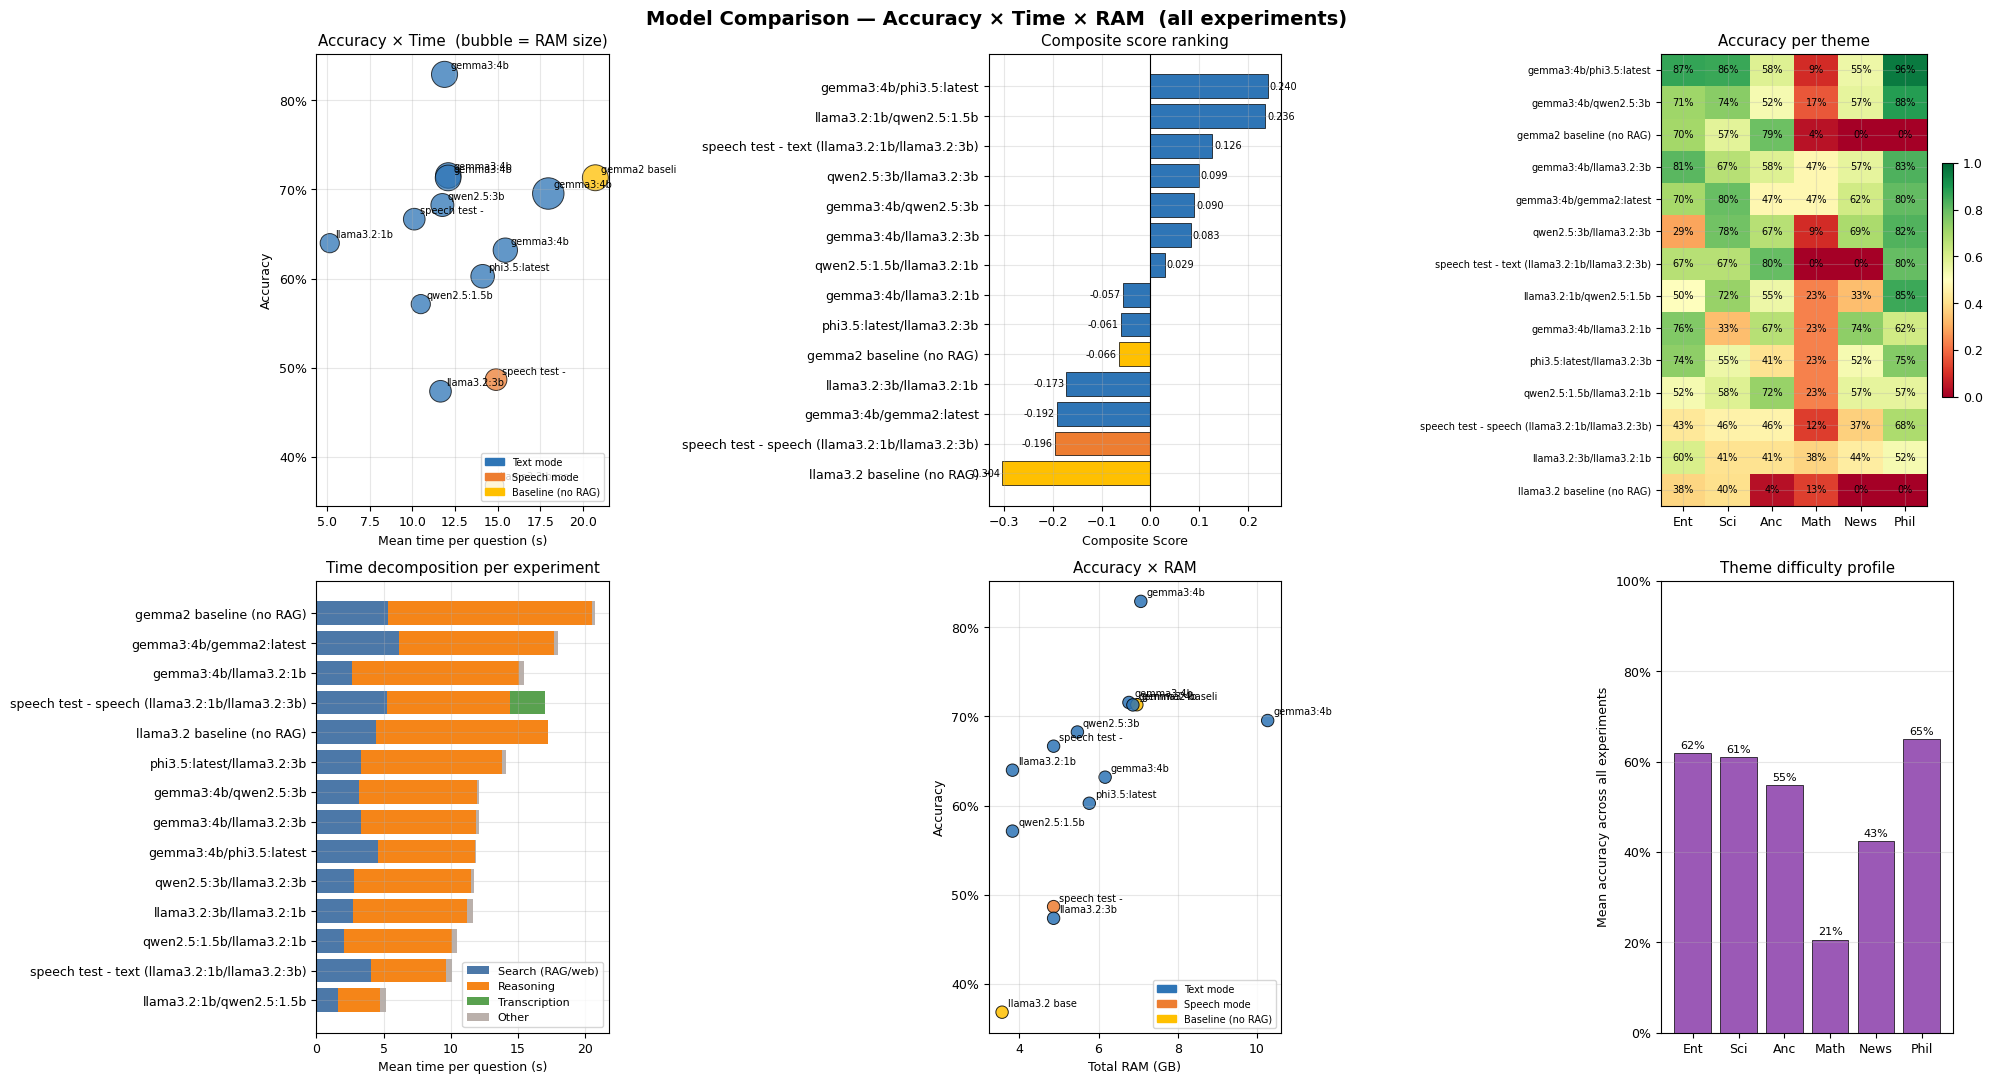

KEY FINDINGS
  Highest accuracy : gemma3:4b/phi3.5:latest                          82.90%  (11.89s, 7.07 GB)
  Best composite   : gemma3:4b/phi3.5:latest                          score=0.240
  Speech vs text   : 48.68% vs 66.67% (−18.0% accuracy, +4.8s/question, 2.63s of which is transcription)
  gemma2 baseline (no RAG) : 71.31% accuracy
  llama3.2 baseline (no RAG) : 36.84% accuracy
  Math bottleneck  : avg accuracy = 20.6%  (worst theme across all experiments)


In [8]:
# ── Load metrics_only.xlsx ────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

XLSX = os.path.join(marcelo_root, "metrics_only.xlsx")
df = pd.read_excel(XLSX)
df = df.dropna(subset=["Experiment"]).reset_index(drop=True)
df = df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

if "Mode" not in df.columns:
    df["Mode"] = "text"
df["Mode"] = df["Mode"].fillna("text")

def _color(row):
    mode = str(row.get("Mode", "text")).lower()
    exp  = str(row.get("Experiment", "")).lower()
    if mode == "speech":
        return "#ED7D31"
    elif "baseline" in exp:
        return "#FFC000"
    return "#2E75B6"

df["_color"] = df.apply(_color, axis=1)

# Ranking table
display_cols = ["Experiment", "Accuracy", "Mean Time (s)", "Total RAM (GB)",
                "Acc / GB", "Composite Score", "Mode"]
ranking_display = df[display_cols].style.format({
    "Accuracy": "{:.2%}", "Acc / GB": "{:.2%}",
    "Mean Time (s)": "{:.2f}", "Total RAM (GB)": "{:.2f}",
    "Composite Score": "{:.3f}",
}).background_gradient(subset=["Accuracy", "Composite Score"], cmap="RdYlGn") \
  .background_gradient(subset=["Mean Time (s)", "Total RAM (GB)"], cmap="RdYlGn_r")
display(ranking_display)

legend_patches = [
    mpatches.Patch(color="#2E75B6", label="Text mode"),
    mpatches.Patch(color="#ED7D31", label="Speech mode"),
    mpatches.Patch(color="#FFC000", label="Baseline (no RAG)"),
]

plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.3})

theme_cols   = ["Ent Acc.", "Sci Acc.", "Anc Acc.", "Math Acc.", "News Acc.", "Phil Acc."]
theme_labels = ["Ent", "Sci", "Anc", "Math", "News", "Phil"]

# ═══════════════════════════════════════════════════════════════════════════
# Figure 1 — General comparison (all experiments)
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Model Comparison — Accuracy × Time × RAM  (all experiments)",
             fontsize=14, fontweight="bold")

# (1) Bubble: Accuracy × Time (bubble size = RAM)
ax = axes[0, 0]
sizes = (df["Total RAM (GB)"] * 50).values
ax.scatter(df["Mean Time (s)"], df["Accuracy"], s=sizes, c=df["_color"],
           alpha=0.75, edgecolors="black", linewidths=0.7)
for _, r in df.iterrows():
    ax.annotate(r["Experiment"].split("/")[0][:13],
                (r["Mean Time (s)"], r["Accuracy"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean time per question (s)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy × Time  (bubble = RAM size)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# (2) Composite score bar (sorted ascending)
ax = axes[0, 1]
order = df.sort_values("Composite Score", ascending=True)
ax.barh(order["Experiment"], order["Composite Score"],
        color=order["_color"].values, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Composite Score")
ax.set_title("Composite score ranking")
ax.axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(order["Composite Score"]):
    offset = 0.004 if v >= 0 else -0.004
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, i, f"{v:.3f}", va="center", ha=ha, fontsize=7)

# (3) Heatmap — accuracy per theme
ax = axes[0, 2]
mat = df[theme_cols].fillna(0).values
im = ax.imshow(mat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(theme_labels)))
ax.set_xticklabels(theme_labels)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Experiment"], fontsize=7)
ax.set_title("Accuracy per theme")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.0%}", ha="center", va="center",
                fontsize=7, color="black")
plt.colorbar(im, ax=ax, fraction=0.04)

# (4) Stacked bar — time breakdown: search / reasoning / transcription / other
ax = axes[1, 0]
order2 = df.sort_values("Mean Time (s)")
tr   = order2["Mean Transcription (s)"].fillna(0) if "Mean Transcription (s)" in order2 else pd.Series(np.zeros(len(order2)), index=order2.index)
base = pd.Series(np.zeros(len(order2)), index=order2.index)
ax.barh(order2["Experiment"], order2["Mean Search (s)"].fillna(0),
        color="#4c78a8", label="Search (RAG/web)")
base += order2["Mean Search (s)"].fillna(0)
ax.barh(order2["Experiment"], order2["Mean Reasoning (s)"].fillna(0),
        left=base, color="#f58518", label="Reasoning")
base += order2["Mean Reasoning (s)"].fillna(0)
ax.barh(order2["Experiment"], tr, left=base, color="#59a14f", label="Transcription")
base += tr
other = (order2["Mean Time (s)"] - base).clip(lower=0)
ax.barh(order2["Experiment"], other, left=base, color="#bab0ab", label="Other")
ax.set_xlabel("Mean time per question (s)")
ax.set_title("Time decomposition per experiment")
ax.legend(loc="lower right", fontsize=8)

# (5) Accuracy × RAM
ax = axes[1, 1]
ax.scatter(df["Total RAM (GB)"], df["Accuracy"], s=80, c=df["_color"],
           edgecolors="black", linewidths=0.7, alpha=0.85)
for _, r in df.iterrows():
    ax.annotate(r["Experiment"].split("/")[0][:13],
                (r["Total RAM (GB)"], r["Accuracy"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Total RAM (GB)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy × RAM")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(handles=legend_patches, fontsize=7, loc="lower right")

# (6) Theme difficulty profile — average across all experiments
ax = axes[1, 2]
theme_avg = df[theme_cols].fillna(0).mean()
ax.bar(theme_labels, theme_avg.values, color="#9b59b6", edgecolor="black", linewidth=0.5)
ax.set_ylabel("Mean accuracy across all experiments")
ax.set_title("Theme difficulty profile")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for i, v in enumerate(theme_avg.values):
    ax.text(i, v + 0.01, f"{v:.0%}", ha="center", fontsize=8)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


# ── Key findings ──────────────────────────────────────────────────────────
best_acc   = df.iloc[0]
best_score = df.sort_values("Composite Score", ascending=False).iloc[0]
base_mask  = df["Experiment"].str.contains("baseline", na=False, case=False)

print("=" * 78)
print("KEY FINDINGS")
print("=" * 78)
print(f"  Highest accuracy : {best_acc['Experiment']:<48} {best_acc['Accuracy']:.2%}"
      f"  ({best_acc['Mean Time (s)']:.2f}s, {best_acc['Total RAM (GB)']:.2f} GB)")
print(f"  Best composite   : {best_score['Experiment']:<48} score={best_score['Composite Score']:.3f}")
if st is not None and ss is not None:
    acc_drop = st["Accuracy"] - ss["Accuracy"]
    time_add = ss["Mean Time (s)"] - st["Mean Time (s)"]
    tr_time  = ss.get("Mean Transcription (s)", 0) or 0
    print(f"  Speech vs text   : {ss['Accuracy']:.2%} vs {st['Accuracy']:.2%} "
          f"(−{acc_drop:.1%} accuracy, +{time_add:.1f}s/question, {tr_time:.2f}s of which is transcription)")
if base_mask.any():
    for _, br in df[base_mask].iterrows():
        print(f"  {br['Inference Model']} baseline (no RAG) : {br['Accuracy']:.2%} accuracy")
print(f"  Math bottleneck  : avg accuracy = {df['Math Acc.'].fillna(0).mean():.1%}  (worst theme across all experiments)")

### Results

- The best experiment correctly answered **83% of questions** — a strong result for a fully local, CPU-only setup.
- The **speech mode** was successfully tested without any timeouts, at the cost of **18 percentage points of accuracy** compared to the text baseline (transcription noise compounds across questions).
- Comparing the RAG experiments against the no-RAG baselines (gemma2 and llama3.2) confirms that RAG consistently improves accuracy when the corpus is large and relevant.
- Routing different themes to dedicated models and strategies proved highly effective, particularly for Math (PoT) and History/News (web search), where a single general strategy would have failed.

### Conclusions

* **Mixed RAG Performance:** Counterintuitively, the implementation of RAG sometimes degraded the guesser's performance. This occurred primarily due to the increased prompt size caused by the injected context, which frequently led to timeouts. Furthermore, the retrieved context was occasionally irrelevant because not every category has a high-quality, comprehensive database. However, for the *Science and Nature* theme (the largest database), RAG proved to be a critical and effective feature, as the LLM successfully leveraged the retrieved information to improve accuracy.

* **The Math Bottleneck:** Math remains a severe challenge. Under the current hardware and time constraints, answering math questions consistently appears unfeasible. Using smaller models avoids timeouts but frequently results in hallucinated or incorrect arithmetic. Conversely, using larger, more capable models inevitably triggers timeouts. Despite exhaustive efforts to optimise this pipeline (such as the PoT approach), hardware limitations remain a hard blocker for complex local mathematical inference.

* **Thematic Agentic Separation:** Isolating the environment — routing to specific prompts and models based on the question's theme — significantly improved the overall architecture and quality of the project. This was highly effective because the API already provided the theme categorisation. If we had been required to implement an additional LLM classification step to determine the theme for every question, the added processing overhead might have negated the benefits of this separation.

* **The Critical Role of Prompt Engineering:** Tailoring prompts to specific tasks proved essential. Prompt engineering allowed us to strictly enforce output formats and dictate the reasoning approach. It is crucial to align the prompt with the paradigm the model was trained on. For instance, while most math models are fine-tuned for Chain of Thought (CoT), some are specifically trained for Program of Thought (PoT). Matching the prompt architecture to the model's training significantly improves output quality. Below are two examples of highly specialised prompts used in the system:

    **Prompt for Entertainment (Direct Classification & RAG):**

    ```text
    QA_PROMPT_TMPL_STR_ENTERTAINMENT = (
        "You are an expert in entertainment and pop culture. Use the context to answer the question.\n"
        "--- CONTEXT ---\n"
        "{context}\n"
        "----------------\n"
        "QUESTION:\n{question}\n\n"
        "OPTIONS:\n{options}\n\n"
        "Output ONLY the index number (0, 1, 2, or 3) of the correct answer.\n"
        "CRITICAL: Do NOT include any other text, words, or explanations. Just the DIGIT.\n\n"
        "If there's NO INFORMATION about the question in the CONTEXT, REASON with your own knowledge.\n"
        "MANDATORY: You MUST output exactly ONE digit (0, 1, 2, or 3). NEVER refuse. NEVER say 'I cannot' or 'I don't know'. If uncertain, output your best guess as a single digit.\n"
        "Final Option Index: "
    )
    ```

    **Prompt for Math (Program of Thought / Code Generation):**

    ```text
    QA_PROMPT_TMPL_STR_MATHS_POT = (
        "Solve this math problem using Python. Output ONLY one ```python code block.\n\n"
        "{context}"
        "QUESTION: {question}\n\n"
        "OPTIONS: {options}\n\n"
        "Environment (already available):\n"
        "- `from sympy import *` (symbols, solve, integrate, diff, Matrix, etc.)\n"
        "- `import math, statistics`\n"
        "- `PYTHON_OPTIONS = {options_list}` (list of option strings)\n\n"
        "Rules:\n"
        "- Compute the answer numerically or symbolically.\n"
        "- Last line MUST be `print(index)` where index is 0, 1, 2, or 3.\n\n"
        "Example:\n"
        "```python\n"
        "from sympy import *\n"
        "x = symbols('x')\n"
        "result = solve(x**2 - 4, x)\n"
        "ans = float(max(result))\n"
        "print(PYTHON_OPTIONS.index(str(int(ans))) if str(int(ans)) in PYTHON_OPTIONS else 0)\n"
        "```\n\n"
        "Your solution:\n"
    )
    ```

* **Few-Shot Prompting Limitations:** While few-shot prompting is generally a powerful technique, it proved unviable in this specific setup. For very small models, concatenating few-shot examples alongside the RAG context quickly saturates the context window. This cognitive overload caused the smaller models to hallucinate, lose track of the core instructions, and completely fail to adhere to the mandatory output format constraints.


## References

- Lewis, P. et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS.
- Programming of Thoughts (PoT) : https://medium.com/@ThePromptIndex/program-of-thoughts-everything-you-need-to-know-7ebf2cb9d59c
- RRF ReRanker: https://medium.com/@devalshah1619/mathematical-intuition-behind-reciprocal-rank-fusion-rrf-explained-in-2-mins-002df0cc5e2a